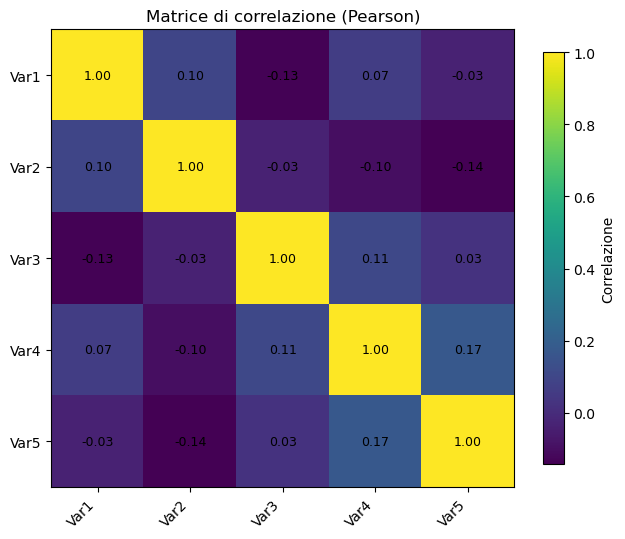

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def esercizio1(seed: int = 42, n : int = 200) -> pd.DataFrame:
    """
    Creiamo datatset sintetico a 5 variabili numeriche
    poi calcoliamo e visualizziamo la matrice di corrrelazione
    """

    np.random.seed(seed)

    df = pd.DataFrame({
        "Var1" : np.random.normal(0,1,n),
        "Var2": np.random.normal(5, 2, n),
        "Var3": np.random.normal(-2, 1, n),
        "Var4": np.random.normal(10, 3, n),
        "Var5": np.random.normal(0, 5, n),
    })

    corr = df.corr(numeric_only=True)

    # Plot "heatmap" con Matplotlib (senza Seaborn)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(corr.to_numpy(), aspect="auto")
    ax.set_title("Matrice di correlazione (Pearson)")
    ax.set_xticks(range(len(corr.columns)), labels=corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)), labels=corr.index)

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, shrink=0.9, label="Correlazione")
    fig.tight_layout()
    plt.show()

    return df

df = esercizio1()

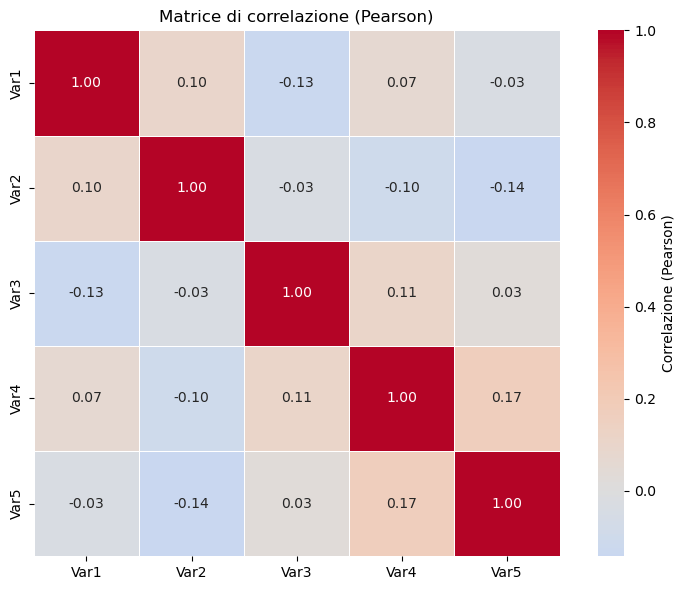

In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def esercizio1_con_seaborn(seed: int = 42, n: int = 200) -> pd.DataFrame:
    """
    Crea un dataset sintetico con 5 variabili numeriche,
    calcola la matrice di correlazione e la visualizza con Seaborn.
    """
    np.random.seed(seed)

    df = pd.DataFrame({
        "Var1": np.random.normal(0, 1, n),
        "Var2": np.random.normal(5, 2, n),
        "Var3": np.random.normal(-2, 1, n),
        "Var4": np.random.normal(10, 3, n),
        "Var5": np.random.normal(0, 5, n),
    })

    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,          # scrive i valori nelle celle
        fmt=".2f",           # formato delle annotazioni
        cmap="coolwarm",     # palette (come nelle slide)
        center=0,            # centra la colormap sullo zero
        square=True,         # celle quadrate (più “pulito”)
        linewidths=0.5,      # separatori tra celle
        cbar_kws={"label": "Correlazione (Pearson)"}
    )
    plt.title("Matrice di correlazione (Pearson)")
    plt.tight_layout()
    plt.show()

    return df

df = esercizio1_con_seaborn()

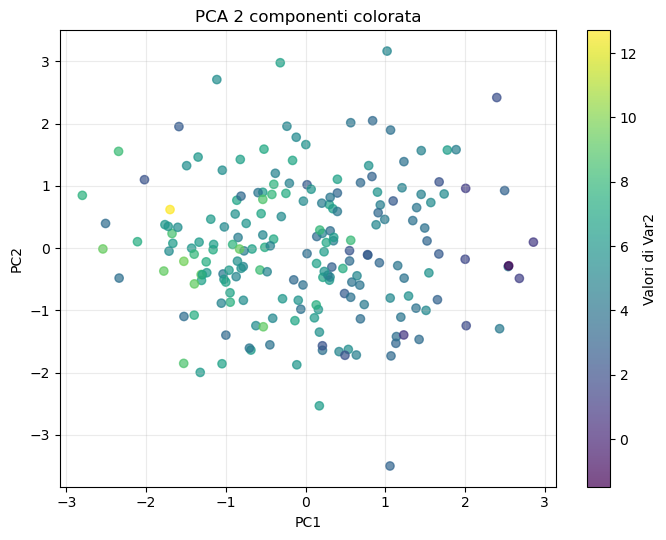

Varianza spiegata: [0.26502281 0.2220628 ]


In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def esercizio2_PCA(df, color_col="Var2"):
    """
    PCA a 2 componenti su un DataFrame
    Standardizziamo le variabili con scale diverse
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df.to_numpy())

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    sc = ax.scatter(X_2d[:,0], X_2d[:,1], c=df[color_col].to_numpy(), alpha=0.7)
    fig.colorbar(sc, ax=ax, label=f"Valori di {color_col}")
    ax.set_title("PCA 2 componenti colorata")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()

    return pca.explained_variance_ratio_

evr= esercizio2_PCA(df, "Var2")
print("Varianza spiegata:", evr)




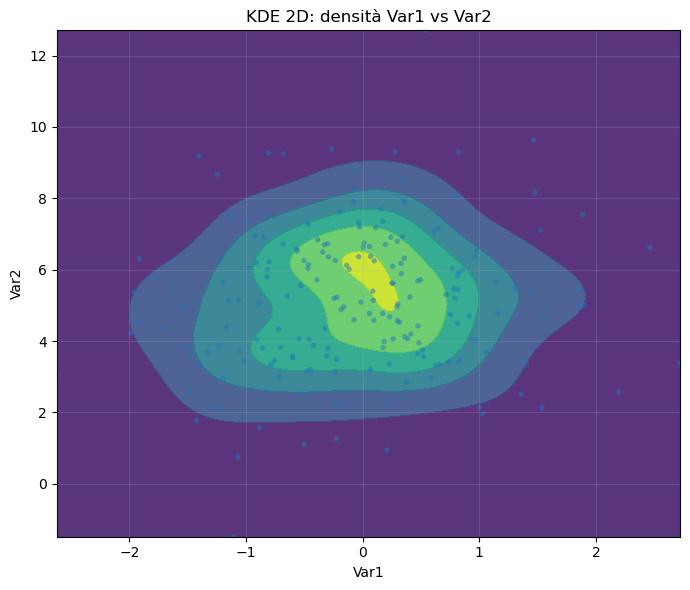

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def esercizio3_kde2d(x, y):
    """
    Densità 2D stimata via gaussian_kde e visualizzata con contourf.
    """

    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)

    xx, yy = np.meshgrid(
        np.linspace(x.min(), x.max(), 200), 
        np.linspace(y.min(), y.max(), 200),
    )
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7,6))

    cf= ax.contourf(xx, yy, zz, alpha=0.9, levels=5)
    ax.scatter(x, y, s=15, alpha=0.5, edgecolors="none")
    ax.set_title("KDE 2D: densità Var1 vs Var2")
    ax.set_xlabel("Var1")
    ax.set_ylabel("Var2")
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()

esercizio3_kde2d(df["Var1"].to_numpy(), df["Var2"].to_numpy())




In [101]:
import numpy as np
from scipy.stats import gaussian_kde

def debug_kde_matrici(x, y, m=5):
    # 1) dati originali
    print("x shape:", x.shape)
    print("y shape:", y.shape)
    print("x (prime 5):", x[:5])
    print("y (prime 5):", y[:5])
    print()

    # 2) xy: (2, n)
    xy = np.vstack([x, y])
    print("xy = vstack([x, y]) shape:", xy.shape)
    print("xy (prime 5 colonne):\n", xy[:, :5])
    print()

    # 3) KDE costruita sui dati
    kde = gaussian_kde(xy)
    print("kde costruita: gaussian_kde(xy)")
    print()

    # 4) griglia piccola (m x m) per ispezione
    x_grid = np.linspace(x.min(), x.max(), m)
    y_grid = np.linspace(y.min(), y.max(), m)
    print("x_grid:", x_grid)
    print("y_grid:", y_grid)
    print()

    xx, yy = np.meshgrid(x_grid, y_grid)
    print("xx shape:", xx.shape)
    print("yy shape:", yy.shape)
    print("xx:\n", xx)
    print("yy:\n", yy)
    print()

    # 5) “appiattisco” la griglia e la preparo per KDE
    grid = np.vstack([xx.ravel(), yy.ravel()])
    print("grid = vstack([xx.ravel(), yy.ravel()]) shape:", grid.shape)
    print("grid (prime 10 colonne):\n", grid[:, :10])
    print()

    # 6) valuto KDE sui punti della griglia
    z_flat = kde(grid)  # vettore lungo m*m
    print("z_flat shape:", z_flat.shape)
    print("z_flat (prime 10):", z_flat[:10])
    print()

    zz = z_flat.reshape(xx.shape)
    print("zz shape:", zz.shape)
    print("zz (matrice densità):\n", zz)

# ESEMPIO: usa i tuoi dati
debug_kde_matrici(df["Var1"].to_numpy(), df["Var2"].to_numpy(), m=5)

x shape: (200,)
y shape: (200,)
x (prime 5): [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
y (prime 5): [5.71557472 6.12156905 7.16610249 7.1076041  2.24466126]

xy = vstack([x, y]) shape: (2, 200)
xy (prime 5 colonne):
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [ 5.71557472  6.12156905  7.16610249  7.1076041   2.24466126]]

kde costruita: gaussian_kde(xy)

x_grid: [-2.6197451  -1.28476654  0.05021203  1.3851906   2.72016917]
y_grid: [-1.48253468  2.06446474  5.61146415  9.15846357 12.70546298]

xx shape: (5, 5)
yy shape: (5, 5)
xx:
 [[-2.6197451  -1.28476654  0.05021203  1.3851906   2.72016917]
 [-2.6197451  -1.28476654  0.05021203  1.3851906   2.72016917]
 [-2.6197451  -1.28476654  0.05021203  1.3851906   2.72016917]
 [-2.6197451  -1.28476654  0.05021203  1.3851906   2.72016917]
 [-2.6197451  -1.28476654  0.05021203  1.3851906   2.72016917]]
yy:
 [[-1.48253468 -1.48253468 -1.48253468 -1.48253468 -1.48253468]
 [ 2.06446474  2.06446474  2.06446474 